In [1]:
# ================================================================================
# EXPLANATION: FEATURE ANALYSIS & ABLATION STRATEGY FOR DDI MODELING
# ================================================================================

# This document breaks down our strategy for analyzing drug similarity features 
# (Structural vs. ATC) and validating them through an ablation study prior to 
# building our binary classification model for Drug-Drug Interactions (DDIs).

# --------------------------------------------------------------------------------
# 1. THE TWO LENSES OF DRUG SIMILARITY
# --------------------------------------------------------------------------------
# To predict adverse DDIs, we need to represent drugs numerically. We are comparing 
# two fundamentally different ways of measuring drug similarity:

# * Structural Similarity (ECFP / Morgan Fingerprints):
#   - Bottom-up, chemical approach.
#   - Computed purely from the 2D molecular graph (atoms and bonds) using the 
#     Tanimoto coefficient to measure local chemical environment overlap.
#   - Blind spot: Knows nothing about biology, receptors, or clinical use.

# * ATC Similarity (Anatomical Therapeutic Chemical Classification):
#   - Top-down, expert-curated clinical approach.
#   - Measures hierarchy levels shared between drugs based on organ system, 
#     therapeutic intent, and pharmacological properties.
#   - Blind spot: Knows nothing about underlying chemical structure.

# --------------------------------------------------------------------------------
# 2. WHY ANALYZE FEATURE DIVERGENCE?
# --------------------------------------------------------------------------------
# Before model training, we want to map out where structural and ATC similarities 
# diverge across drug-drug pairs:

# * High Structure / Low ATC: Close chemical analogs that have been repurposed 
#   for completely unrelated clinical indications.
# * Low Structure / High ATC: Structurally unrelated scaffolds that converge on 
#   the same receptor, enzyme, or pathway through completely different binding 
#   chemistry (often called "scaffold hopping").

# --------------------------------------------------------------------------------
# 3. IMPLICATIONS FOR THE CLASSIFIER (REDUNDANCY VS. COMPLEMENTARITY)
# --------------------------------------------------------------------------------
# This statistical analysis directly informs feature redundancy:
# * If the correlation between structural and ATC similarity is low, they capture 
#   largely non-overlapping variance across drug pairs.
# * This argues for complementarity: concatenating them gives the classifier two 
#   largely independent axes of information to split on (chemical reactivity vs. 
#   clinical context).

# --------------------------------------------------------------------------------
# 4. VALIDATION VIA ABLATION STUDY
# --------------------------------------------------------------------------------
# Statistical correlation alone doesn't prove performance value. We must run an 
# ablation study holding model architecture and hyperparameters completely fixed:

# 1. Train on Morgan-only features
# 2. Train on ATC-only features
# 3. Train on Concatenated features (Morgan + ATC)

# * Metric Focus: Compare performance using AUC-ROC and AUPRC. 
# * Note on AUPRC: Because DDI datasets are heavily class-imbalanced (non-interacting 
#   pairs vastly outnumber interacting pairs), AUPRC is critical here. AUC-ROC can 
#   be overly optimistic, whereas AUPRC strictly evaluates performance on the 
#   minority class of true adverse interactions.
# ================================================================================

## What "convergence" and "divergence" mean in this notebook

This notebook uses the terms in two related but distinct senses:

**1. Pairwise (per drug-pair) convergence/divergence** -- for a single drug pair, do two
similarity lenses (e.g. structural vs. ATC) agree or disagree?
- **Convergent / concordant pair**: both metrics point the same direction -- either both low
  (the pair looks dissimilar under every lens) or both high (the pair looks similar under every
  lens). These are the pairs sitting in the bottom-left or top-right of the quadrant scatterplot.
- **Divergent pair**: the metrics disagree -- one lens says "similar," the other says "not
  similar." These are the off-diagonal quadrants:
  - *High structure / low ATC* ("repurposed analogs"): chemically near-identical molecules used
    for unrelated clinical indications.
  - *Low structure / high ATC* ("scaffold hopping"): chemically unrelated molecules that
    nonetheless converge on the same therapeutic class/target.

**2. Population-level (feature-level) convergence/divergence** -- across the *entire* dataset,
do two similarity metrics move together systematically (measured by Pearson/Spearman
correlation)?
- **Convergent features** (high correlation): the two metrics are largely redundant -- knowing
  one tells you most of what you need to know about the other, so combining them adds little
  new information to a classifier.
- **Divergent features** (correlation near 0): the two metrics are largely independent -- each
  captures variance the other misses, which is exactly the property that makes concatenating
  them useful for a downstream binary classifier (more non-overlapping axes to split on).

The quadrant/scatter analysis below applies sense (1) to structural vs. ATC similarity
specifically; the correlation-matrix analysis later extends sense (2) to every similarity layer
(biological identity ladder, GO aspects, Pfam, pathway native/inferred, ATC, structural).


### Note: Whether there is low or high similarity is based on the threshold, adjust threshold to be reasonable for the given feature

In [2]:
import os
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
adverse_atc_sim_df = pd.read_parquet("C:\\Users\\ashto\\ddi-prediction\\notebooks\\h2_pharmacological_similarity\\adverse_atc_sim.parquet")
non_interacting_atc_sim_df = pd.read_parquet("C:\\Users\\ashto\\ddi-prediction\\notebooks\\h2_pharmacological_similarity\\non_interacting_atc_sim.parquet")
adverse_morgan_sim_df = pd.read_parquet("C:\\Users\\ashto\\ddi-prediction\\notebooks\\h3_structural_similarity\\adverse_structural_sim.parquet")
non_interacting_morgan_sim_df = pd.read_parquet("C:\\Users\\ashto\\ddi-prediction\\notebooks\\h3_structural_similarity\\non_interacting_structural_sim.parquet")

In [4]:
def merge_structural_and_atc(atc_df, morgan_df, atc_score_col='atc_similarity_score',
                              struct_score_col='similarity_score'):
    """
    Combine separately computed ATC and Morgan structural similarity tables into a
    single frame with unified 'atc_sim' and 'structural_sim' columns.

    Rows are matched by (drug1_id, drug2_id) rather than by position/index, so the
    two inputs do not need to share row order or index values. Because
    (drug1_id, drug2_id) is not unique in the non-interacting sets (duplicate sampled
    pairs), a plain key-based merge would blow up into a cartesian product for
    duplicated pairs. To avoid that, we also merge on `_occurrence`, the 0-based rank
    of each row within its (drug1_id, drug2_id) group (in each table's own row order),
    which pairs up duplicates 1st-with-1st, 2nd-with-2nd, etc.
    """
    if len(atc_df) != len(morgan_df):
        raise ValueError(f"Row count mismatch: atc_df has {len(atc_df):,} rows, morgan_df has {len(morgan_df):,} rows")

    atc_df = atc_df.reset_index(drop=True).copy()
    morgan_df = morgan_df.reset_index(drop=True).copy()

    atc_df['_occurrence'] = atc_df.groupby(['drug1_id', 'drug2_id']).cumcount()
    morgan_df['_occurrence'] = morgan_df.groupby(['drug1_id', 'drug2_id']).cumcount()

    merged = atc_df.merge(
        morgan_df[['drug1_id', 'drug2_id', '_occurrence', struct_score_col]],
        on=['drug1_id', 'drug2_id', '_occurrence'],
        how='inner',
        validate='one_to_one',
    )

    if len(merged) != len(atc_df):
        missing = len(atc_df) - len(merged)
        raise ValueError(
            f"{missing:,} rows in atc_df had no matching (drug1_id, drug2_id) pair/duplicate-count "
            "in morgan_df -- the two tables do not represent the same set of drug pairs."
        )

    merged['structural_sim'] = merged[struct_score_col]
    merged['atc_sim'] = merged[atc_score_col]
    merged = merged.drop(columns=['_occurrence'])

    return merged


adverse_combined_df = merge_structural_and_atc(adverse_atc_sim_df, adverse_morgan_sim_df)
non_interacting_combined_df = merge_structural_and_atc(non_interacting_atc_sim_df, non_interacting_morgan_sim_df)


In [5]:

def analyze_similarity_statistics(df, struct_col='structural_sim', atc_col='atc_sim', 
                                  struct_threshold=0.7, atc_threshold=0.2,
                                  label='unknown',
                                  output_filename='similarity_divergence_analysis.png'):
    """
    Performs statistical correlation and divergence analysis on pre-calculated 
    structural and ATC similarities for drug-drug pairs.
    """
    # 1. Clean data: Drop pairs where either similarity score is missing
    df_clean = df.dropna(subset=[struct_col, atc_col]).copy()
    total_pairs = len(df_clean)
    
    print("==================================================")
    print("1. STATISTICAL CORRELATION RESULTS")
    print("==================================================")
    
    # Calculate correlations
    # Spearman is robust for similarity distributions which are rarely perfectly normal
    pearson_corr, _ = pearsonr(df_clean[struct_col], df_clean[atc_col])
    spearman_corr, _ = spearmanr(df_clean[struct_col], df_clean[atc_col])

    print(f"THIS ANALYSIS IS FOR {label.upper()} PAIRS")
    print(f"Morgan Fingerprint Threshold: {struct_threshold}")
    print(f"ATC Similarity Threshold: {atc_threshold}")
    
    print(f"Total valid drug pairs analyzed: {total_pairs:,}")
    print(f"Pearson Correlation:  {pearson_corr:.4f}")
    print(f"Spearman Correlation: {spearman_corr:.4f}\n")
    
    print("Interpretation:")
    print("-> A correlation close to 0 supports the 'complementarity' argument.")
    print("-> It indicates the features capture largely non-overlapping variance,")
    print("-> justifying concatenating both for the binary classification model.")
    
    print("\n==================================================")
    print("2. DIVERGENCE ANALYSIS (QUADRANT BREAKDOWN)")
    print("==================================================")
    
    # Categorize pairs into the four quadrants
    df_clean['category'] = 'Concordant (Low Struct / Low ATC)' # Default background
    
    # Concordant High
    mask_high_both = (df_clean[struct_col] >= struct_threshold) & (df_clean[atc_col] >= atc_threshold)
    df_clean.loc[mask_high_both, 'category'] = 'Concordant (High Struct / High ATC)'
    
    # (a) Divergent: High Structure, Low ATC (Repurposed analogs)
    mask_high_struct_low_atc = (df_clean[struct_col] >= struct_threshold) & (df_clean[atc_col] < atc_threshold)
    df_clean.loc[mask_high_struct_low_atc, 'category'] = '(a) High Struct / Low ATC (Repurposed)'
    
    # (b) Divergent: Low Structure, High ATC (Scaffold hopping)
    mask_low_struct_high_atc = (df_clean[struct_col] < struct_threshold) & (df_clean[atc_col] >= atc_threshold)
    df_clean.loc[mask_low_struct_high_atc, 'category'] = '(b) Low Struct / High ATC (Scaffold Hop)'

    # Print the distribution
    counts = df_clean['category'].value_counts()
    for cat in df_clean['category'].unique():
        count = counts.get(cat, 0)
        pct = (count / total_pairs) * 100
        print(f"{cat:<40}: {count:>7,} pairs ({pct:>5.1f}%)")

    print("\n==================================================")
    print("3. VISUALIZATION")
    print("==================================================")
    
    # Set up the plot aesthetics
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    # Define custom colors for the categories
    palette = {
        'Concordant (Low Struct / Low ATC)': "#111010",        # Light grey
        'Concordant (High Struct / High ATC)': "#06e919",      # Darker grey
        '(a) High Struct / Low ATC (Repurposed)': '#1f77b4',   # Blue
        '(b) Low Struct / High ATC (Scaffold Hop)': '#d62728'  # Red
    }
    
    # Create scatter plot
    sns.scatterplot(
        data=df_clean, 
        x=struct_col, 
        y=atc_col, 
        hue='category',
        palette=palette,
        alpha=0.6,
        s=40 # point size
    )
    
    # Add quadrant threshold lines
    plt.axvline(x=struct_threshold, color='black', linestyle='--', alpha=0.5)
    plt.axhline(y=atc_threshold, color='black', linestyle='--', alpha=0.5)
    
    # Formatting
    plt.title('Drug Pair Similarity Divergence: Structure vs. ATC', fontsize=14, pad=15)
    plt.xlabel('Structural Similarity (e.g., Tanimoto)', fontsize=12)
    plt.ylabel('ATC Similarity (Hierarchical)', fontsize=12)
    
    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    
    output_path = os.path.join('figures', output_filename)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully as '{output_path}'")
    
    return df_clean

1. STATISTICAL CORRELATION RESULTS
THIS ANALYSIS IS FOR ADVERSE PAIRS
Morgan Fingerprint Threshold: 0.7
ATC Similarity Threshold: 0.2
Total valid drug pairs analyzed: 478,324
Pearson Correlation:  0.2934
Spearman Correlation: 0.1036

Interpretation:
-> A correlation close to 0 supports the 'complementarity' argument.
-> It indicates the features capture largely non-overlapping variance,
-> justifying concatenating both for the binary classification model.

2. DIVERGENCE ANALYSIS (QUADRANT BREAKDOWN)
(b) Low Struct / High ATC (Scaffold Hop):  16,640 pairs (  3.5%)
Concordant (Low Struct / Low ATC)       : 461,502 pairs ( 96.5%)
Concordant (High Struct / High ATC)     :     154 pairs (  0.0%)
(a) High Struct / Low ATC (Repurposed)  :      28 pairs (  0.0%)

3. VISUALIZATION
Plot saved successfully as 'figures\adverse_similarity_divergence_analysis.png'


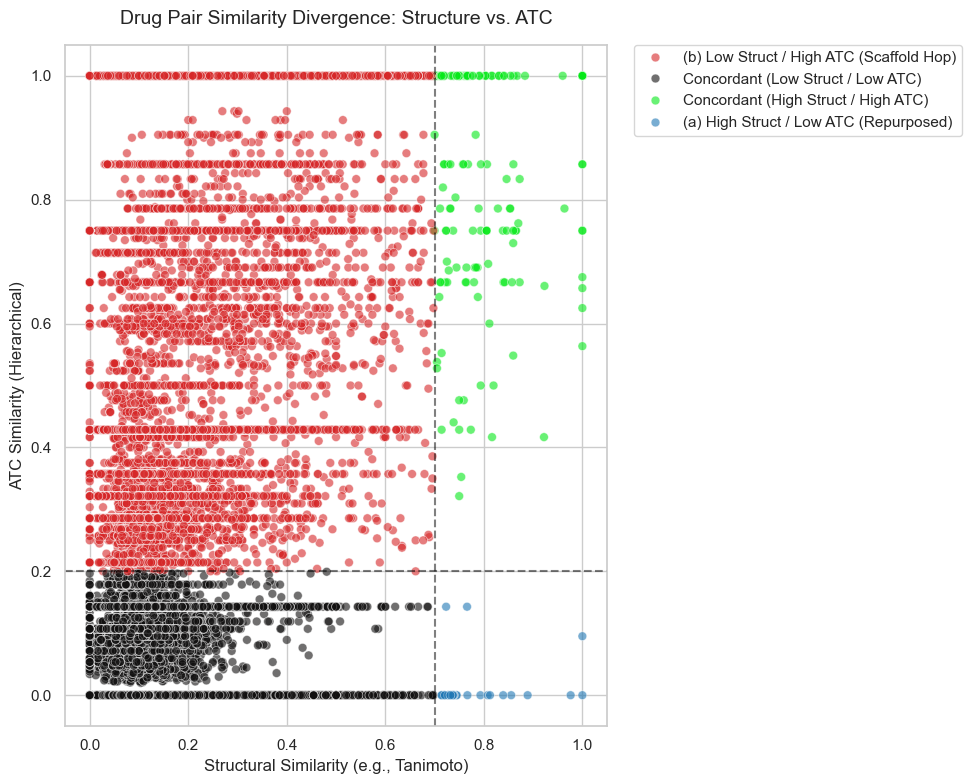

In [6]:
adverse_analysis_df = analyze_similarity_statistics(adverse_combined_df, label = 'adverse', output_filename='adverse_similarity_divergence_analysis.png')



1. STATISTICAL CORRELATION RESULTS
THIS ANALYSIS IS FOR NON_INTERACTING PAIRS
Morgan Fingerprint Threshold: 0.7
ATC Similarity Threshold: 0.2
Total valid drug pairs analyzed: 162,893
Pearson Correlation:  0.1311
Spearman Correlation: 0.0460

Interpretation:
-> A correlation close to 0 supports the 'complementarity' argument.
-> It indicates the features capture largely non-overlapping variance,
-> justifying concatenating both for the binary classification model.

2. DIVERGENCE ANALYSIS (QUADRANT BREAKDOWN)
Concordant (Low Struct / Low ATC)       : 161,311 pairs ( 99.0%)
(b) Low Struct / High ATC (Scaffold Hop):   1,568 pairs (  1.0%)
(a) High Struct / Low ATC (Repurposed)  :       4 pairs (  0.0%)
Concordant (High Struct / High ATC)     :      10 pairs (  0.0%)

3. VISUALIZATION
Plot saved successfully as 'figures\non_interacting_similarity_divergence_analysis.png'


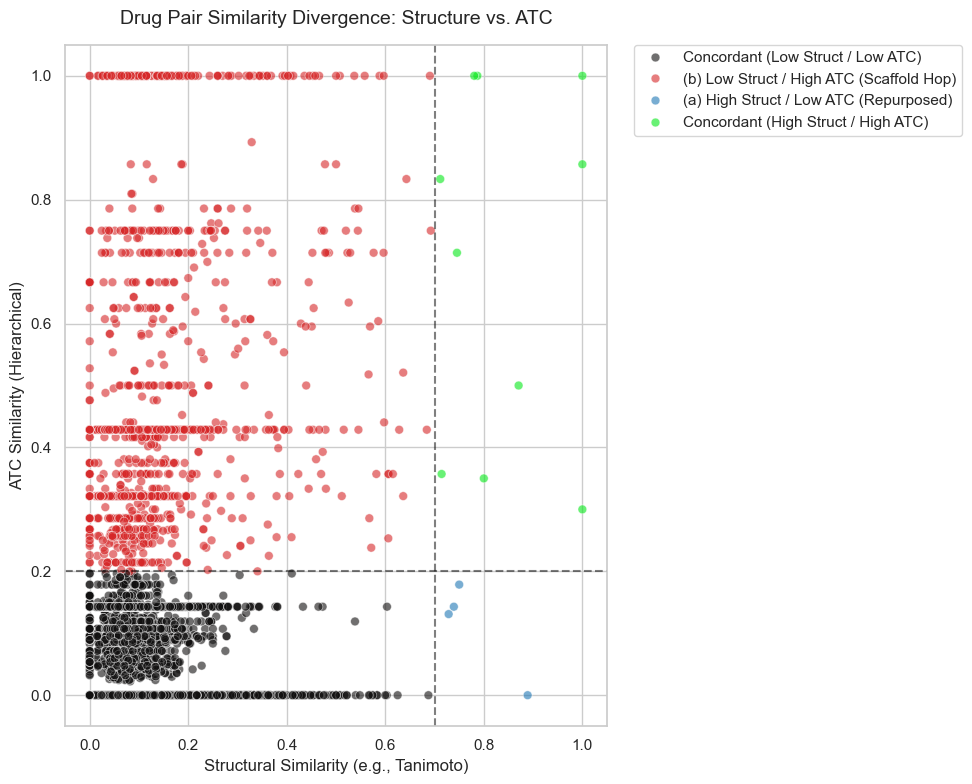

In [7]:
non_interacting_analysis_df = analyze_similarity_statistics(non_interacting_combined_df, label = 'non_interacting', output_filename='non_interacting_similarity_divergence_analysis.png')


## Correlation & divergence analysis across all similarity layers

Same style of analysis as `atc_morgan_analysis.ipynb` (Pearson/Spearman correlation +
high/low quadrant divergence), extended from the single ATC-vs-structural comparison to every
similarity layer now available: biological identity at each ladder level (`identity_L0/L1/L2`),
GO term similarity split by aspect (`go_mf/bp/cc`), both pathway flavors (`pathway_native`,
`pathway_inferred`), plus the existing `atc_sim` and `structural_sim`.


In [8]:
import numpy as np

unified_adverse_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\unified_adverse_df.parquet")
unified_non_interacting_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\unified_non_interacting_df.parquet")

print(f"unified_adverse_df: {unified_adverse_df.shape}")
print(f"unified_non_interacting_df: {unified_non_interacting_df.shape}")


unified_adverse_df: (478324, 31)
unified_non_interacting_df: (162893, 31)


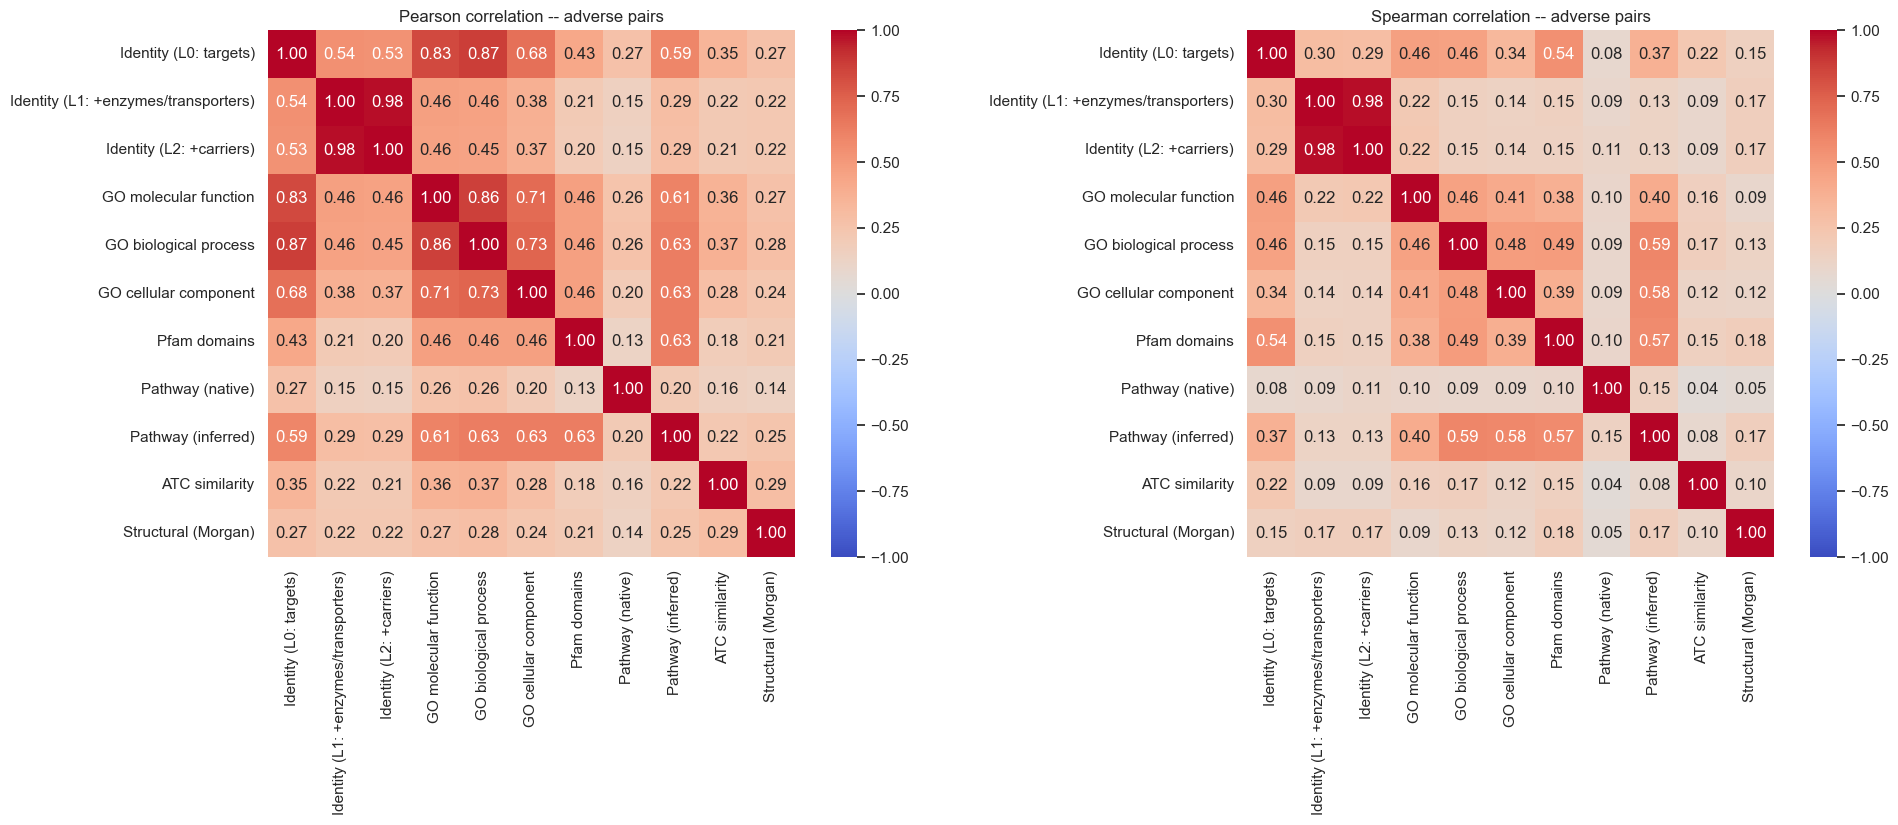


Top absolute Pearson correlations (adverse):
  Identity (L1: +enzymes/transporters) vs Identity (L2: +carriers)           : +0.983
  Identity (L0: targets)              vs GO biological process              : +0.873
  GO molecular function               vs GO biological process              : +0.862
  Identity (L0: targets)              vs GO molecular function              : +0.830
  GO biological process               vs GO cellular component              : +0.729
  GO molecular function               vs GO cellular component              : +0.708
  Identity (L0: targets)              vs GO cellular component              : +0.680
  GO cellular component               vs Pathway (inferred)                 : +0.632
  GO biological process               vs Pathway (inferred)                 : +0.631
  Pfam domains                        vs Pathway (inferred)                 : +0.627


In [9]:
SIM_COLS = [
    'identity_L0_jaccard', 'identity_L1_jaccard', 'identity_L2_jaccard',
    'go_mf_jaccard', 'go_bp_jaccard', 'go_cc_jaccard',
    'pfam_jaccard', 'pathway_native_jaccard', 'pathway_inferred_jaccard',
    'atc_sim', 'structural_sim',
]
SIM_LABELS = {
    'identity_L0_jaccard': 'Identity (L0: targets)', 'identity_L1_jaccard': 'Identity (L1: +enzymes/transporters)',
    'identity_L2_jaccard': 'Identity (L2: +carriers)', 'go_mf_jaccard': 'GO molecular function',
    'go_bp_jaccard': 'GO biological process', 'go_cc_jaccard': 'GO cellular component',
    'pfam_jaccard': 'Pfam domains', 'pathway_native_jaccard': 'Pathway (native)',
    'pathway_inferred_jaccard': 'Pathway (inferred)', 'atc_sim': 'ATC similarity', 'structural_sim': 'Structural (Morgan)',
}


def correlation_matrix_analysis(df, cols, label, output_filename):
    """Pearson + Spearman correlation heatmaps across every similarity layer, plus a ranked
    list of the most correlated non-trivial pairs (excluding trivial same-family ladder pairs)."""
    df_clean = df[cols].dropna()
    display_cols = [SIM_LABELS[c] for c in cols]

    pearson_corr = df_clean.corr(method='pearson')
    spearman_corr = df_clean.corr(method='spearman')
    pearson_corr.columns = pearson_corr.index = display_cols
    spearman_corr.columns = spearman_corr.index = display_cols

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, corr, title in [(axes[0], pearson_corr, 'Pearson'), (axes[1], spearman_corr, 'Spearman')]:
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
        ax.set_title(f'{title} correlation -- {label} pairs')
    plt.tight_layout()
    output_path = os.path.join('figures', output_filename)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()

    print(f"\nTop absolute Pearson correlations ({label}):")
    pairs = pearson_corr.where(~np.tril(np.ones(pearson_corr.shape)).astype(bool)).stack()
    for (a, b), val in pairs.reindex(pairs.abs().sort_values(ascending=False).index)[:10].items():
        print(f"  {a:<35} vs {b:<35}: {val:+.3f}")

    return pearson_corr, spearman_corr


adverse_pearson, adverse_spearman = correlation_matrix_analysis(
    unified_adverse_df, SIM_COLS, 'adverse', 'adverse_similarity_correlation_matrix.png')


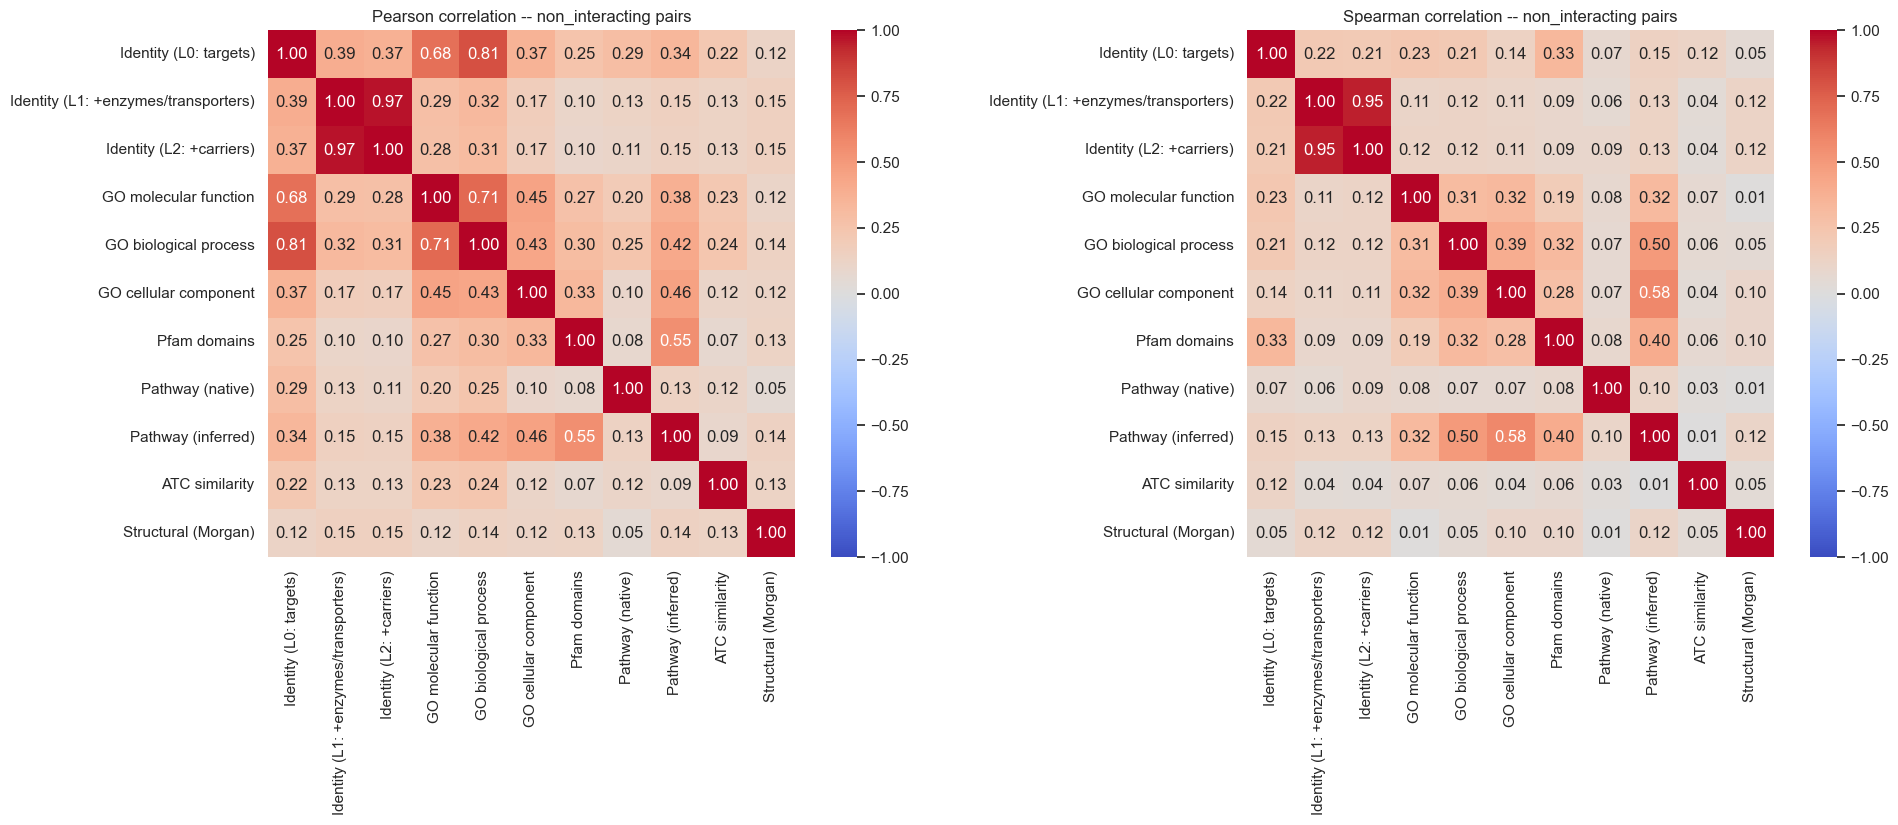


Top absolute Pearson correlations (non_interacting):
  Identity (L1: +enzymes/transporters) vs Identity (L2: +carriers)           : +0.972
  Identity (L0: targets)              vs GO biological process              : +0.809
  GO molecular function               vs GO biological process              : +0.713
  Identity (L0: targets)              vs GO molecular function              : +0.683
  Pfam domains                        vs Pathway (inferred)                 : +0.553
  GO cellular component               vs Pathway (inferred)                 : +0.458
  GO molecular function               vs GO cellular component              : +0.446
  GO biological process               vs GO cellular component              : +0.432
  GO biological process               vs Pathway (inferred)                 : +0.417
  Identity (L0: targets)              vs Identity (L1: +enzymes/transporters): +0.392


In [10]:
non_interacting_pearson, non_interacting_spearman = correlation_matrix_analysis(
unified_non_interacting_df, SIM_COLS, 'non_interacting', 'non_interacting_similarity_correlation_matrix.png')


## In-depth analysis of the convergence/divergence results

**1. Structural vs. ATC quadrant breakdown (pairwise divergence)**

| Category | Adverse (n=478,324) | Non-interacting (n=162,893) |
|---|---|---|
| Concordant (low struct / low ATC) | 96.5% | 99.0% |
| Concordant (high struct / high ATC) | ~0.03% (154) | ~0.006% (10) |
| Divergent -- scaffold hop (low struct / high ATC) | 3.5% (16,640) | 1.0% (1,568) |
| Divergent -- repurposed (high struct / low ATC) | ~0.006% (28) | ~0.002% (4) |

- The overwhelming majority of pairs in *both* sets are trivially concordant-low: structurally
  and clinically unrelated. This is expected for a combinatorial pairing of thousands of drugs.
- True concordant-high pairs (chemically similar analogs in the same ATC class) are vanishingly
  rare in both sets -- structural and ATC similarity essentially never "double-confirm" each
  other, so this quadrant contributes almost no signal either way.
- "Repurposed analogs" (high structure / low ATC) are essentially absent (<0.01% either set).
  Near-identical scaffolds used for unrelated indications basically don't occur in this data.
- The interesting asymmetry is in **scaffold-hopping** divergence (low structure / high ATC):
  it's **3.5x more common among adverse pairs than non-interacting pairs** (3.5% vs 1.0%).
  Structurally unrelated drugs that share a clinical/therapeutic classification are
  disproportionately represented among *adverse* DDIs -- consistent with adverse interactions
  often being driven by shared pharmacodynamic mechanism/receptor class rather than shared
  chemistry. This supports keeping ATC similarity as a feature: it captures real interaction
  risk that structural similarity alone misses.
- This is reflected in the overall correlation too: Pearson(structural, ATC) is weak in both
  sets (0.29 adverse vs. 0.13 non-interacting) and Spearman weaker still (0.10 vs. 0.05) --
  the two lenses are largely independent, i.e. divergent at the population level, which is the
  basis for combining both as complementary classifier features.

**2. Full similarity-layer correlation matrix (feature-level convergence/divergence)**

- **Convergent (redundant) cluster**: `identity_L1` and `identity_L2` are almost collinear
  (Pearson 0.98 adverse / 0.97 non-interacting) since L2 only adds carrier proteins on top of
  L1's enzymes/transporters -- one of these two ladder levels is largely redundant given the
  other. `identity_L0` (raw target overlap) also converges strongly with `go_bp`/`go_mf`
  (0.87/0.83 adverse, 0.81/0.68 non-interacting): shared targets mechanically drive shared GO
  annotations, so these aren't independent signals, they're different views of the same
  underlying target overlap.
- **Divergent (complementary) features**: `atc_sim` and `structural_sim` stay weakly correlated
  with the biological identity/GO/Pfam block across the board (mostly 0.1-0.4 Pearson, lower
  under Spearman), and with each other (0.29 adverse / 0.13 non-interacting). `pathway_native`
  is the most decorrelated feature of all (0.13-0.29 Pearson with everything else in adverse,
  even lower in non-interacting) -- the curated/native pathway signal is capturing something
  the inferred-neighbor and identity/GO features don't.
- **Adverse vs. non-interacting structure differs**: the biological block correlates more
  tightly *within* the adverse set than the non-interacting set (e.g. `identity_L0` vs. `go_bp`
  is 0.87 vs. 0.81; `atc_sim` sits at 0.22-0.37 against biological features in adverse vs.
  0.09-0.24 in non-interacting). Adverse pairs are enriched for drugs that genuinely share
  mechanism, so their similarity features move together more than in the broader,
  largely-unrelated non-interacting population.
- **Practical implication for the DDI classifier**: `identity_L1`/`identity_L2` and the
  GO-aspect trio are internally redundant enough that including all of them likely yields
  diminishing returns -- consider collapsing the identity ladder to L0 + L2 only, or dropping
  one GO aspect. In contrast, `atc_sim`, `structural_sim`, and `pathway_native` remain
  comparatively decorrelated from the rest and from each other, so they're the strongest
  candidates for adding genuinely non-redundant (complementary) axes to the feature set.
